In [1]:
import os
import torch, torchvision
from torch import nn
from torchvision import datasets, transforms
from torchvision.models import resnet152
from torch.utils.data import DataLoader
import timm

from collections import Counter
import gc
from time import sleep
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from IPython.display import display


#Utilities shared between models
import helpers as h

gc.collect()
torch.cuda.empty_cache()

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda device


# ResNet-152

## Config

In [ ]:
#Config

modelName = "ResNet-152"
modelPath = f"Models/{modelName}.pth"
historyPath = f"Models/{modelName}_history.csv" #recorded stats during training
statePath = f"Models/{modelName}_state.pth"  #optimizer & current epoch

purge = False   #Start a new model from scratch
training = False  #Whether to train the model or just load it

#Paralell training examples 
BATCH_SIZE = 4   #GPU a limit
#CPU workers to load data to gpu
WORKERS = 8   #Ezt még talán lehet növelni

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4


## Loading / initializing resources

### DataLoader and dataset parameters

In [3]:
train_loader = h.GetTrainingDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
val_loader = h.GetValDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
test_loader = h.GetTestDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)

ClassNames = train_loader.dataset.classes
numClasses = len(ClassNames)

print(f"Classes: {ClassNames}")
print(f"Number of classes: {numClasses}")

Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Dermatofibroma', 'Melanocytic nevi', 'Melanoma', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 8


In [ ]:
#Deriving Inverse frequency of classes to balance rare classes
totalSamples = len(train_loader.dataset) #+ len(test_loader.dataset) + len(val_loader.dataset)

samplesPerClass = Counter(train_loader.dataset.targets) 
#samplesPerClass.update(Counter(test_loader.dataset.targets))
#samplesPerClass.update(Counter(val_loader.dataset.targets))

inverseFrequencies = [ totalSamples/(numClasses * samplesPerClass[i]) for i in range(numClasses) ]
#freqvInv = [3.652, 0.953, 1.207, 13.248, 0.246, 0.700, 5.042, 12.515]  #from excel

print(totalSamples)
print(inverseFrequencies)

25331
[3.652104959630911, 0.9528663857959675, 1.2066977896341464, 13.248430962343097, 0.24593203883495146, 0.7002156125608138, 5.041998407643312, 12.515316205533598]


### Model

In [5]:
model = resnet152(weights=None)
model.fc = nn.Linear(model.fc.in_features, numClasses)

### Loss function and optimizer

In [6]:
#LossFN and Optimizer
#criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=torch.tensor(inverseFrequencies))
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

### Loading if available

In [7]:
#Loading or initializing model and statistics

epochs_done = 0
history = None

if not purge and os.path.exists(modelPath):
    model.load_state_dict(torch.load(modelPath))    #this loads latest model, not bestVal
    state = torch.load(statePath)
    optimizer.load_state_dict(state["optimizer"])
    epochs_done = state["epoch"]
    #load recorded stats too
    history = pd.read_csv(historyPath)
    print("Loaded last state")


## Training

In [8]:
model = model.to(device)
criterion = criterion.to(device)

In [ ]:
#Training config (=epoch overwrites)
#0 = off, priority: stopAt > maxOW
stopAt = 0
maxEpochOW = 70

#stopAt = 10    #stop at specific epoch
epochs = h.MAX_EPOCHS
if maxEpochOW: epochs = maxEpochOW
if stopAt: epochs = stopAt

if training:
    bestTrainAcc = 0.0
    bestValAcc = 0.0
    if history is not None and len(history) > 0:
        bestTrainAcc = history["train_acc"].max()
        bestValAcc = history["val_acc"].max()

    
    for epoch in range(epochs_done, epochs):
        print(f"Epoch {epoch+1}/{epochs} \t| ", end="")
        #Executing training and validation
        train_loss, train_acc = h.trainingEpoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, CM = h.validate(model, val_loader, criterion, device)

        print(
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f}, val acc: {val_acc:.4f}"
        )
        epochs_done += 1

        #Recording statistics
        sampleRow = {
            "epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc
        }
        sampleRow.update(h.FlattenCM(CM))
        if history is None:
            history = pd.DataFrame(columns=sampleRow.keys())
        history.loc[len(history)] = sampleRow

        #Saving snapshot
        torch.save(model.state_dict(), modelPath)
        torch.save({
                "epoch": epoch+1,
                "optimizer": optimizer.state_dict()
            }, statePath)
        history.to_csv(historyPath, index=False)

        #saving best model
        if val_acc > bestValAcc:
            bestValAcc = val_acc
            torch.save(model.state_dict(), f"Models/{modelName}_bestVal.pth")
        
        if epoch == epochs-1: break
        sleep(90) #Let GPU cool a little

else:
    print("Already trained")

display(history)

Epoch 61/70 	| train loss: 0.9851, train acc: 0.6763 | val loss: 0.9459, val acc: 0.6548
Epoch 62/70 	| train loss: 0.9698, train acc: 0.6783 | val loss: 0.9169, val acc: 0.6785
Epoch 63/70 	| train loss: 0.9695, train acc: 0.6817 | val loss: 0.8733, val acc: 0.6762
Epoch 64/70 	| train loss: 0.9591, train acc: 0.6789 | val loss: 0.8958, val acc: 0.6655
Epoch 65/70 	| train loss: 0.9658, train acc: 0.6849 | val loss: 0.9192, val acc: 0.6722
Epoch 66/70 	| train loss: 0.9396, train acc: 0.6819 | val loss: 0.8769, val acc: 0.6880
Epoch 67/70 	| train loss: 0.9431, train acc: 0.6840 | val loss: 0.9502, val acc: 0.6655
Epoch 68/70 	| train loss: 0.9380, train acc: 0.6844 | val loss: 0.9027, val acc: 0.6667
Epoch 69/70 	| train loss: 0.9334, train acc: 0.6901 | val loss: 0.9636, val acc: 0.6588
Epoch 70/70 	| train loss: 0.9280, train acc: 0.6934 | val loss: 0.9560, val acc: 0.6722


,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,...,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,1.812523,0.447932,1.348016,0.530645,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1.727766,0.491314,1.481543,0.439304,14,27,9,1,13,...,0,0,0,0,0,0,0,0,0,0
2,3,1.692549,0.502468,1.814146,0.446817,0,2,0,0,0,...,6,3,0,0,0,0,0,0,0,0
3,4,1.643742,0.514954,1.260511,0.572163,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1.600362,0.529267,1.210166,0.573745,0,0,0,0,0,...,0,0,0,2,1,0,5,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,66,0.939622,0.681917,0.876917,0.688019,32,14,19,1,4,...,20,0,0,5,2,0,8,3,0,22
66,67,0.943057,0.683990,0.950229,0.665480,47,25,32,1,9,...,15,0,0,4,4,1,14,3,0,23
67,68,0.937958,0.684434,0.902676,0.666667,41,34,18,1,6,...,20,0,0,2,3,1,5,3,0,23
68,69,0.933353,0.690110,0.963643,0.658758,38,29,21,1,7,...,15,0,0,2,1,0,11,1,0,22


In [32]:
#latest CM
CM = h.ParseCM(history.iloc[-1][5:])
#display(history)
display(CM)

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,36,11,13,1,5,14,10,0
Basal cell carcinoma,17,215,16,1,24,17,6,1
Benign keratosis-like lesions,11,21,119,1,45,44,7,0
Dermatofibroma,5,11,12,17,28,12,9,0
Melanocytic nevi,0,18,43,3,1057,132,4,0
Melanoma,13,31,45,0,107,219,12,0
Squamous cell carcinoma,4,15,7,0,5,5,13,0
Vascular lesions,0,10,7,0,16,9,1,24


## Progress trough training

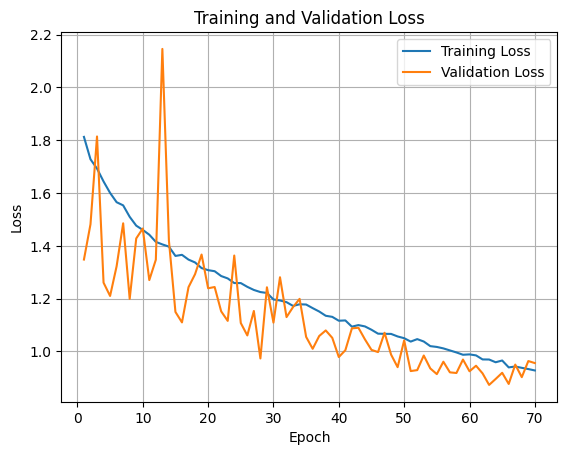

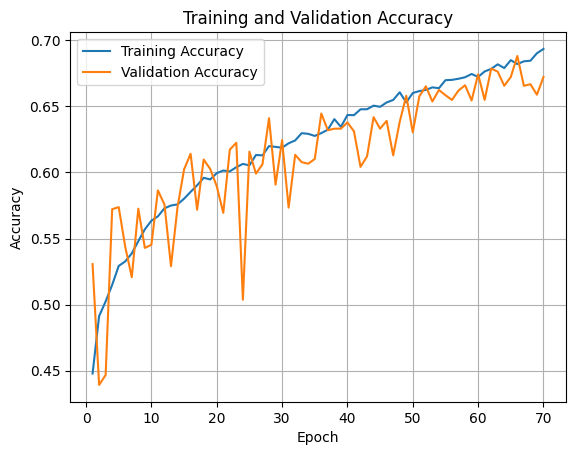

In [33]:
plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="Training Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(history["epoch"], history["train_acc"], label="Training Accuracy")
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

## Trying out trained model

In [37]:
#Testing should be done on best performing model

mpath = f"Models/{modelName}.pth" #latest model
mpath = f"Models/{modelName}_bestVal.pth" #with best validation

model.load_state_dict(torch.load(mpath))

<All keys matched successfully>

### Evaluate on test set

In [38]:
model = model.to(device)

test_loss, test_acc, TEST_CM = h.validate(model, test_loader, criterion, device)

print(f"test loss: {test_loss:.4f}, test acc: {test_acc:.4f}")

test loss: 0.9027, test acc: 0.6878


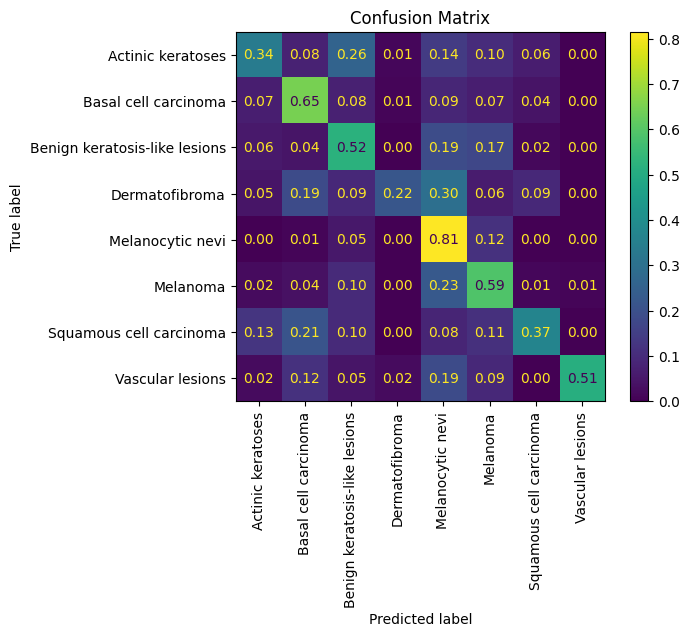

In [39]:
TEST_CM = TEST_CM.apply(pd.to_numeric)

cm_norm = TEST_CM.div(TEST_CM.sum(axis=1), axis=0)

disp = ConfusionMatrixDisplay(
    display_labels=cm_norm.index,
    confusion_matrix=cm_norm.values
)


disp.plot(values_format=".2f")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.show()


### Deriving per class metrics

In [44]:
metrics = {}

for className in TEST_CM.index:
    TP, FN, FP, TN = h.PredictionsPerClass(TEST_CM, className)
    accuracy, precision, recall, f1 = h.ClassMetrics(TP, FN, FP, TN)
    metrics[className] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
metrics = pd.DataFrame(metrics).T
metrics = metrics.mul(100).round(4)
display(metrics)

,accuracy,precision,recall,f1
Actinic keratoses,1.0236,33.7662,29.5455,31.5152
Basal cell carcinoma,10.1575,64.6617,77.4775,70.4918
Benign keratosis-like lesions,3.6614,51.9553,35.3612,42.0814
Dermatofibroma,0.5512,21.8750,56.0000,31.4607
Melanocytic nevi,42.9528,81.4787,84.7050,83.0605
Melanoma,8.5433,58.9674,47.9029,52.8624
Squamous cell carcinoma,1.0236,36.6197,40.6250,38.5185
Vascular lesions,0.8661,51.1628,84.6154,63.7681


### Inspecting with captum

Examining what features are relevant

## Demo

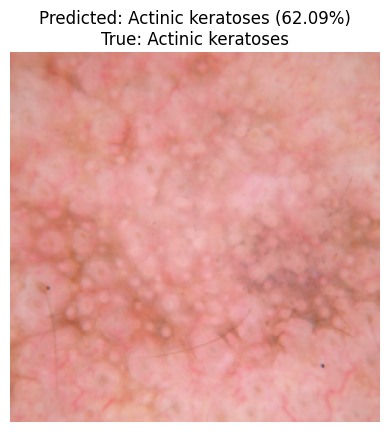

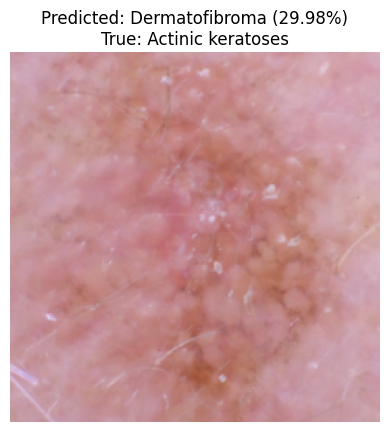

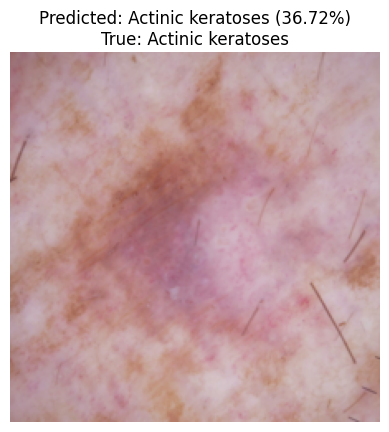

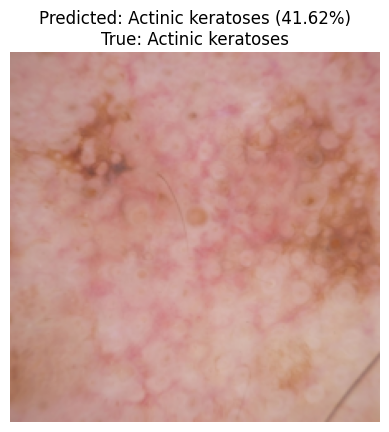

In [ ]:
model.eval()


images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)


for idx in range(len(preds)):
    img = images[idx].cpu()
    true_label = ClassNames[labels[idx].item()]
    pred_label = ClassNames[preds[idx].item()]
    confidence = probs[idx, preds[idx]].item()

    # If image was normalized, unnormalize it before plotting
    mean = torch.tensor(h.MEAN).view(3, 1, 1)
    std = torch.tensor(h.STD).view(3, 1, 1)

    img = img * std + mean
    img = img.clamp(0, 1)

    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
    f"Predicted: {pred_label} ({confidence:.2%})\n"
    f"True: {true_label}"
    )
    plt.show()

